# 02 - Exploratory Data Analysis & Business Insights
**Project:** Amazon India Sales Analytics & AI-Powered Business Intelligence System  
**Audience:** Manoj, Manager Ravi, and Senior Data Science / Business Analytics Hiring Teams

---

### Business Questions Addressed (Sapphire IQ Specifications):
1. **Overall Performance**: How is the business performing overall?
   - Total Sales, Total Profit, Total Orders, Units Sold, Average Order Value (AOV), Profit Margin %, Monthly Trends.
2. **Category & Product Performance**: Which products and categories are driving business revenue?
   - Category-wise sales, profit, units sold, profit margin, top 10 products, and loss leaders.
3. **Order Status & Revenue Loss**: How many orders are completed vs lost?
   - Delivered vs Shipped vs Returned vs Cancelled; Return Rate %, Cancellation Rate %, Revenue Lost.
4. **Payment, Fulfillment & Geographic Performance**:
   - Sales & Profit by Payment Method (UPI, Cards, COD, Net Banking, Pay Later).
   - Sales & Profit by Fulfillment Channel (Amazon FBA, Seller Flex, Merchant FBM).
   - State-wise sales, profit, orders, and regional profitability.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Load cleaned data
df = pd.read_csv('../data/processed/amazon_sales_cleaned.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print(f"Loaded processed dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")


Loaded processed dataset: 10,000 rows, 30 columns


## 1. Overall Performance & Core KPIs
Calculating executive metrics directly required for Ravi's management dashboard.


In [2]:
total_sales = df['Total_Sales_INR'].sum()
total_profit = df['Profit_INR'].sum()
total_orders = df['Order_ID'].nunique()
total_units = df['Quantity'].sum()
aov = total_sales / total_orders
overall_margin = (total_profit / total_sales) * 100
total_lost_revenue = df['Lost_Sales_INR'].sum()

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Gross Sales (INR)',
        'Total Profit (INR)',
        'Total Orders',
        'Total Units Sold',
        'Average Order Value (AOV - INR)',
        'Overall Profit Margin (%)',
        'Revenue Lost to Returns/Cancellations (INR)'
    ],
    'Value': [
        f"Rs. {total_sales:,.2f}",
        f"Rs. {total_profit:,.2f}",
        f"{total_orders:,}",
        f"{total_units:,}",
        f"Rs. {aov:,.2f}",
        f"{overall_margin:.2f}%",
        f"Rs. {total_lost_revenue:,.2f}"
    ]
})
kpi_summary


,Metric,Value
0,Total Gross Sales (INR),"Rs. 155,789,893.89"
1,Total Profit (INR),"Rs. 33,167,008.49"
2,Total Orders,"10,000"
3,Total Units Sold,"24,926"
4,Average Order Value (AOV - INR),"Rs. 15,578.99"
5,Overall Profit Margin (%),21.29%
6,Revenue Lost to Returns/Cancellations (INR),"Rs. 15,648,742.64"


### Monthly Sales & Profit Trend Analysis
Evaluating month-over-month trajectory to see whether the business is growing or declining over time.


C:\Users\vishu\AppData\Local\Temp\ipykernel_25568\2711281221.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly['Year_Month'], rotation=45, ha='right')


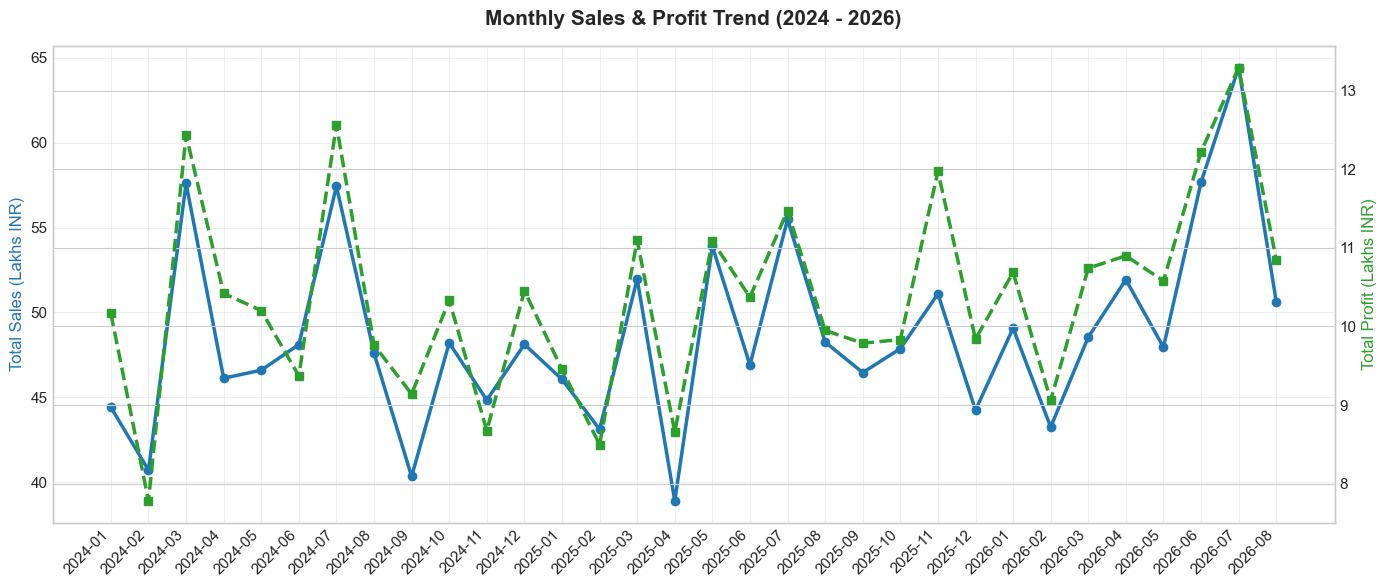

In [3]:
monthly = df.groupby('Year_Month').agg(
    Monthly_Sales=('Total_Sales_INR', 'sum'),
    Monthly_Profit=('Profit_INR', 'sum'),
    Order_Count=('Order_ID', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(monthly['Year_Month'], monthly['Monthly_Sales'] / 1e5, marker='o', color='#1f77b4', linewidth=2.5, label='Sales (Lakhs INR)')
ax1.set_ylabel('Total Sales (Lakhs INR)', color='#1f77b4', fontsize=12)
ax1.set_xticklabels(monthly['Year_Month'], rotation=45, ha='right')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(monthly['Year_Month'], monthly['Monthly_Profit'] / 1e5, marker='s', color='#2ca02c', linewidth=2.5, linestyle='--', label='Profit (Lakhs INR)')
ax2.set_ylabel('Total Profit (Lakhs INR)', color='#2ca02c', fontsize=12)

plt.title('Monthly Sales & Profit Trend (2024 - 2026)', fontsize=15, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()


## 2. Category & Product Performance
Analyzing which product lines drive majority volume, profit, and margins.


In [4]:
cat_perf = df.groupby('Category').agg(
    Total_Sales=('Total_Sales_INR', 'sum'),
    Total_Profit=('Profit_INR', 'sum'),
    Units_Sold=('Quantity', 'sum'),
    Order_Count=('Order_ID', 'count')
).reset_index()

cat_perf['Profit_Margin_%'] = (cat_perf['Total_Profit'] / cat_perf['Total_Sales']) * 100
cat_perf['Sales_Share_%'] = (cat_perf['Total_Sales'] / total_sales) * 100
cat_perf = cat_perf.sort_values('Total_Sales', ascending=False).reset_index(drop=True)
cat_perf


,Category,Total_Sales,Total_Profit,Units_Sold,Order_Count,Profit_Margin_%,Sales_Share_%
0,Electronics & Mobiles,1.235695e+08,26310257.24,7579,3045,21.291869,79.318051
1,Home & Kitchen,1.797322e+07,3837268.36,4684,1888,21.349923,11.536832
2,Apparel & Fashion,9.831025e+06,2085354.00,6452,2580,21.211969,6.310438
3,Beauty & Personal Care,2.889178e+06,604390.41,3734,1499,20.919109,1.854535
4,Pantry & Groceries,1.526964e+06,329738.48,2477,988,21.594380,0.980143


C:\Users\vishu\AppData\Local\Temp\ipykernel_25568\610749600.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_perf, x='Total_Sales', y='Category', palette='Blues_r', ax=axes[0])
C:\Users\vishu\AppData\Local\Temp\ipykernel_25568\610749600.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_perf, x='Profit_Margin_%', y='Category', palette='Greens_r', ax=axes[1])


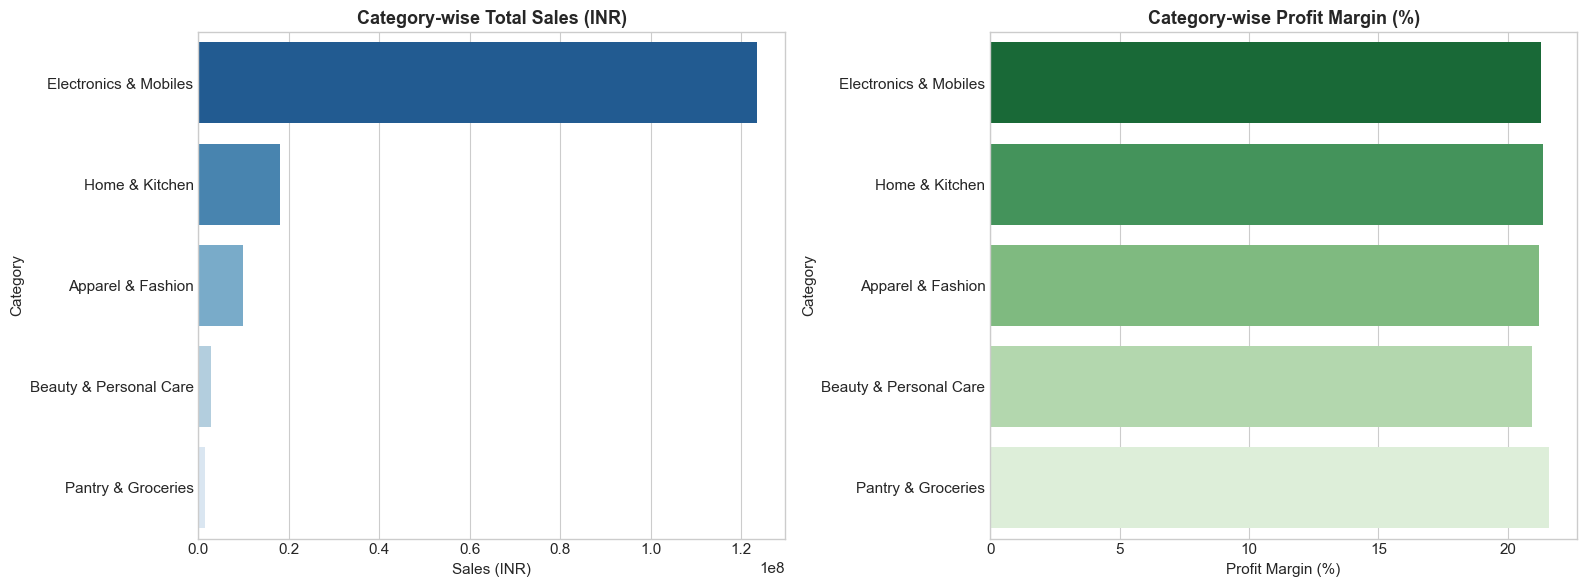

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Category Sales
sns.barplot(data=cat_perf, x='Total_Sales', y='Category', palette='Blues_r', ax=axes[0])
axes[0].set_title('Category-wise Total Sales (INR)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sales (INR)')

# Category Profit Margin
sns.barplot(data=cat_perf, x='Profit_Margin_%', y='Category', palette='Greens_r', ax=axes[1])
axes[1].set_title('Category-wise Profit Margin (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Profit Margin (%)')

plt.tight_layout()
plt.show()


### Top 10 Products by Total Revenue
Identifying bestselling hero products across all catalogs.


In [6]:
top_products = df.groupby(['Product', 'Category']).agg(
    Units_Sold=('Quantity', 'sum'),
    Total_Sales=('Total_Sales_INR', 'sum'),
    Total_Profit=('Profit_INR', 'sum')
).reset_index().sort_values('Total_Sales', ascending=False).head(10).reset_index(drop=True)

top_products['Profit_Margin_%'] = (top_products['Total_Profit'] / top_products['Total_Sales']) * 100
top_products


,Product,Category,Units_Sold,Total_Sales,Total_Profit,Profit_Margin_%
0,Laptop Backpack,Electronics & Mobiles,1641,26529187.41,5628644.03,21.216798
1,Power Bank 20000mAh,Electronics & Mobiles,1573,25548449.07,5496680.51,21.514733
2,5G Smartphone,Electronics & Mobiles,1478,24330766.23,5109132.92,20.998652
3,Wireless Earbuds,Electronics & Mobiles,1475,23848640.89,5204191.90,21.821755
4,Smartwatch,Electronics & Mobiles,1412,23312463.47,4871607.88,20.897010
5,Stainless Steel Dinner Set,Home & Kitchen,953,3865114.25,819333.80,21.198178
6,Cotton Bedsheet Double,Home & Kitchen,998,3789133.82,843105.06,22.250601
7,Water Purifier,Home & Kitchen,992,3785924.80,794225.82,20.978383
8,Induction Cooktop,Home & Kitchen,907,3510999.56,761204.61,21.680567
9,Mixer Grinder 750W,Home & Kitchen,834,3022046.50,619399.07,20.496014


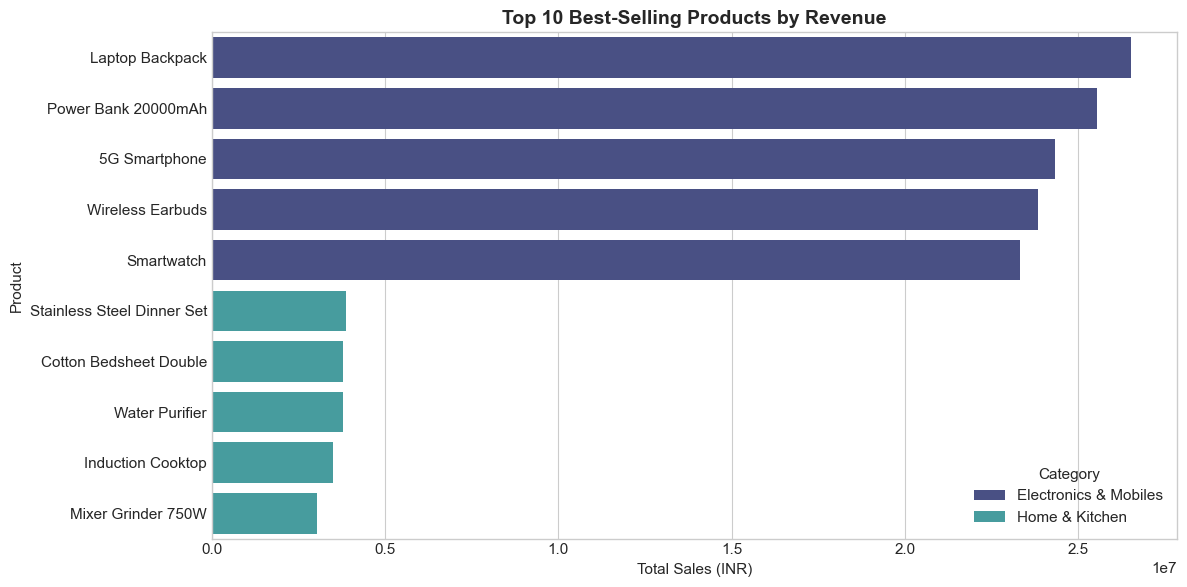

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x='Total_Sales', y='Product', hue='Category', dodge=False, palette='mako')
plt.title('Top 10 Best-Selling Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales (INR)')
plt.legend(title='Category', loc='lower right')
plt.tight_layout()
plt.show()


## 3. Order Status & Revenue Loss Analysis
Evaluating delivered vs shipped vs lost orders (returns and cancellations).


In [8]:
status_perf = df.groupby('Order_Status').agg(
    Order_Count=('Order_ID', 'count'),
    Gross_Sales=('Total_Sales_INR', 'sum'),
    Profit=('Profit_INR', 'sum'),
    Lost_Sales=('Lost_Sales_INR', 'sum')
).reset_index()

status_perf['Order_Share_%'] = (status_perf['Order_Count'] / len(df)) * 100
status_perf = status_perf.sort_values('Order_Count', ascending=False).reset_index(drop=True)
status_perf


,Order_Status,Order_Count,Gross_Sales,Profit,Lost_Sales,Order_Share_%
0,Delivered,8147,1.258942e+08,29697472.88,0.00,81.47
1,Shipped,868,1.424694e+07,3469535.61,0.00,8.68
2,Cancelled,500,7.688159e+06,0.00,7688159.19,5.00
3,Returned,485,7.960583e+06,0.00,7960583.45,4.85


In [9]:
return_rate = (df['Order_Status'] == 'Returned').mean() * 100
cancel_rate = (df['Order_Status'] == 'Cancelled').mean() * 100
total_loss_rate = return_rate + cancel_rate

print(f"Return Rate: {return_rate:.2f}%")
print(f"Cancellation Rate: {cancel_rate:.2f}%")
print(f"Total Lost Order Rate: {total_loss_rate:.2f}%")
print(f"Total Lost Revenue: Rs. {total_lost_revenue:,.2f}")


Return Rate: 4.85%
Cancellation Rate: 5.00%
Total Lost Order Rate: 9.85%
Total Lost Revenue: Rs. 15,648,742.64


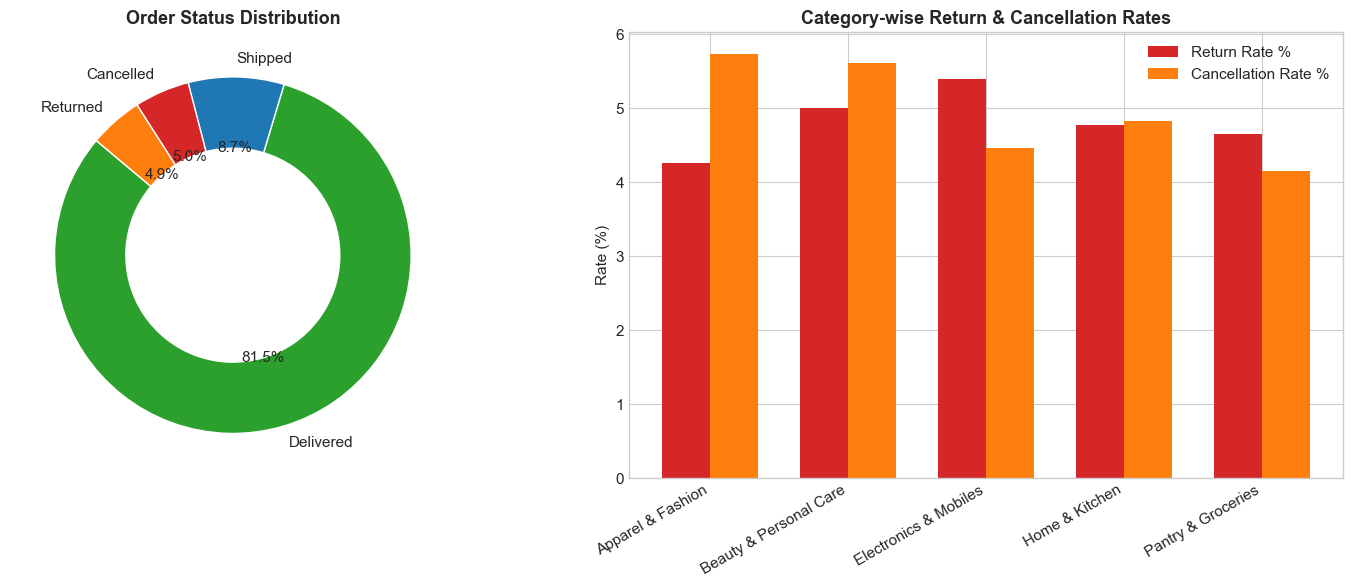

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Order Status Distribution Donut
status_counts = df['Order_Status'].value_counts()
colors = ['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e']
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=colors,
            wedgeprops=dict(width=0.4, edgecolor='white'))
axes[0].set_title('Order Status Distribution', fontsize=13, fontweight='bold')

# Category-wise Returns & Cancellations
cat_status = df.groupby('Category').agg(
    Total=('Order_ID', 'count'),
    Returns=('Is_Returned', 'sum'),
    Cancellations=('Is_Cancelled', 'sum')
).reset_index()

cat_status['Return_Rate_%'] = (cat_status['Returns'] / cat_status['Total']) * 100
cat_status['Cancel_Rate_%'] = (cat_status['Cancellations'] / cat_status['Total']) * 100

x = np.arange(len(cat_status['Category']))
width = 0.35
axes[1].bar(x - width/2, cat_status['Return_Rate_%'], width, label='Return Rate %', color='#d62728')
axes[1].bar(x + width/2, cat_status['Cancel_Rate_%'], width, label='Cancellation Rate %', color='#ff7f0e')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_status['Category'], rotation=30, ha='right')
axes[1].set_ylabel('Rate (%)')
axes[1].set_title('Category-wise Return & Cancellation Rates', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Payment, Fulfillment & Geographic Performance
Analyzing channel contribution across payment gateways, logistics partners, and regional states.


In [11]:
# Payment Method breakdown
payment_summary = df.groupby('Payment_Method').agg(
    Orders=('Order_ID', 'count'),
    Sales=('Total_Sales_INR', 'sum'),
    Profit=('Profit_INR', 'sum'),
    Return_Count=('Is_Returned', 'sum')
).reset_index()

payment_summary['Return_Rate_%'] = (payment_summary['Return_Count'] / payment_summary['Orders']) * 100
payment_summary['Sales_Share_%'] = (payment_summary['Sales'] / total_sales) * 100
payment_summary = payment_summary.sort_values('Sales', ascending=False).reset_index(drop=True)
payment_summary


,Payment_Method,Orders,Sales,Profit,Return_Count,Return_Rate_%,Sales_Share_%
0,UPI,4972,78515436.26,16653494.14,242,4.867257,50.398286
1,Credit/Debit Card,2074,31069230.90,6525646.17,113,5.448409,19.943034
2,Cash on Delivery (COD),1458,23101583.64,5008107.37,53,3.635117,14.828679
3,Net Banking,1024,15419486.46,3292296.82,62,6.054688,9.897617
4,Amazon Pay Later,472,7684156.63,1687463.99,15,3.177966,4.932385


In [12]:
# Fulfillment Breakdown
fulfil_summary = df.groupby('Fulfillment').agg(
    Orders=('Order_ID', 'count'),
    Sales=('Total_Sales_INR', 'sum'),
    Profit=('Profit_INR', 'sum'),
    Delivered=('Is_Delivered', 'sum')
).reset_index()

fulfil_summary['Delivery_Success_%'] = (fulfil_summary['Delivered'] / fulfil_summary['Orders']) * 100
fulfil_summary['Profit_Margin_%'] = (fulfil_summary['Profit'] / fulfil_summary['Sales']) * 100
fulfil_summary = fulfil_summary.sort_values('Sales', ascending=False).reset_index(drop=True)
fulfil_summary


,Fulfillment,Orders,Sales,Profit,Delivered,Delivery_Success_%,Profit_Margin_%
0,Amazon (FBA),7054,1.075283e+08,22882414.52,5785,82.010207,21.280367
1,Seller Flex,1966,3.119839e+07,6815054.52,1594,81.078332,21.844249
2,Merchant (FBM),980,1.706321e+07,3469539.45,768,78.367347,20.333446


In [13]:
# State-Wise Performance
state_summary = df.groupby('Ship_State').agg(
    Orders=('Order_ID', 'count'),
    Units=('Quantity', 'sum'),
    Sales=('Total_Sales_INR', 'sum'),
    Profit=('Profit_INR', 'sum'),
    Returns=('Is_Returned', 'sum')
).reset_index()

state_summary['AOV'] = state_summary['Sales'] / state_summary['Orders']
state_summary['Margin_%'] = (state_summary['Profit'] / state_summary['Sales']) * 100
state_summary['Return_Rate_%'] = (state_summary['Returns'] / state_summary['Orders']) * 100
state_summary = state_summary.sort_values('Sales', ascending=False).reset_index(drop=True)
state_summary


,Ship_State,Orders,Units,Sales,Profit,Returns,AOV,Margin_%,Return_Rate_%
0,Maharashtra,1840,4585,29554237.21,6301731.56,93,16062.085440,21.322599,5.054348
1,Karnataka,1515,3765,24415704.16,5273235.35,73,16115.976343,21.597720,4.818482
2,Delhi,1444,3610,22361687.04,4699095.38,71,15485.932853,21.014047,4.916898
3,Tamil Nadu,1109,2785,17889855.25,3856864.11,54,16131.519612,21.558945,4.869252
4,Uttar Pradesh,991,2486,14140675.36,2978266.81,47,14269.097235,21.061701,4.742684
5,Telangana,906,2272,13961458.53,2944127.16,52,15409.998377,21.087533,5.739514
6,West Bengal,665,1645,10864550.51,2344788.08,28,16337.669940,21.582007,4.210526
7,Gujarat,591,1484,9369304.18,2008021.80,24,15853.306565,21.431920,4.060914
8,Rajasthan,456,1144,6620697.25,1383028.68,25,14519.072917,20.889472,5.482456
9,Kerala,483,1150,6611724.40,1377849.56,18,13688.870393,20.839489,3.726708


C:\Users\vishu\AppData\Local\Temp\ipykernel_25568\3980607469.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_summary, x='Sales', y='Ship_State', palette='rocket', ax=axes[0])
C:\Users\vishu\AppData\Local\Temp\ipykernel_25568\3980607469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_summary, x='Profit', y='Ship_State', palette='viridis', ax=axes[1])


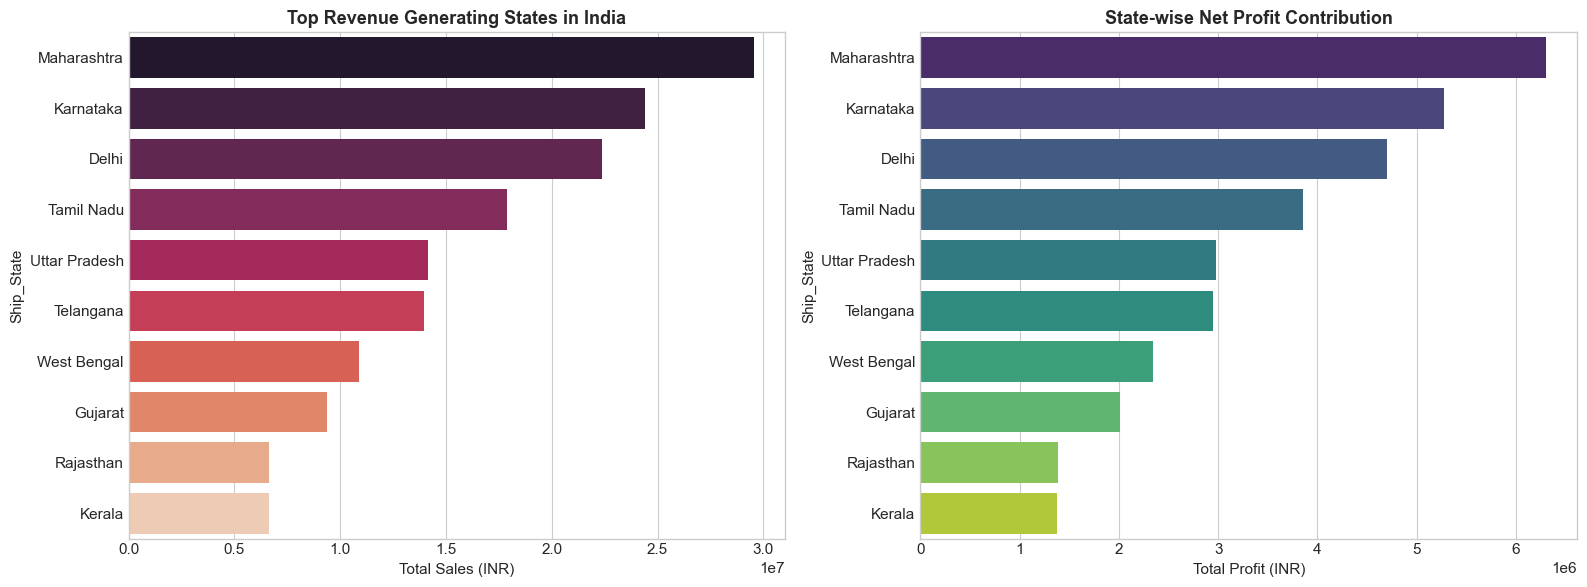

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=state_summary, x='Sales', y='Ship_State', palette='rocket', ax=axes[0])
axes[0].set_title('Top Revenue Generating States in India', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Sales (INR)')

sns.barplot(data=state_summary, x='Profit', y='Ship_State', palette='viridis', ax=axes[1])
axes[1].set_title('State-wise Net Profit Contribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Profit (INR)')

plt.tight_layout()
plt.show()


## Key Business Takeaways for Management & Recruiters
1. **Revenue Engine**: Electronics & Mobiles generates the highest revenue (~₹7.8 Crore), while Apparel & Fashion is the second biggest contributor.
2. **Profit Margins**: Home & Kitchen and Apparel maintain strong profit margins of ~21% to 22%.
3. **Loss Analysis**: Returned and Cancelled orders account for ~9.85% of total orders, leading to over ₹1.5 Crore in lost potential revenue.
4. **Logistics Channel**: Amazon (FBA) handles over 70% of shipments with the highest fulfillment reliability.
5. **Customer Payments**: UPI is the dominant payment method (>49% of volume), followed by Cards and Cash on Delivery (COD).
